# Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

# Acessando a base limpa

In [2]:
df = pd.read_csv('../data/processed/pede_consolidado_limpo.csv')

# Feature Engeneering

Defenindo o Alvo

In [3]:
df['ALVO_RISCO'] = ((df['IDA'] < 6) | (df['IAN'] < 7)).astype(int)

Codificando colunas

In [4]:
map_pedra = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4, 'Não Classificado': 0}
df['PEDRA_NUM'] = df['Pedra'].map(map_pedra)

In [5]:
df['PV_BIN'] = df['Atingiu PV'].map({'Sim': 1, 'Não': 0})

# Modelo

Separação e Treinamento

In [6]:
features_honestas = ['IAA', 'IEG', 'IPS', 'IPP', 'IPV', 'PEDRA_NUM', 'PV_BIN']

In [7]:
X = df[features_honestas]
y = df['ALVO_RISCO']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

Medição do modelo e feature importance

In [10]:
previsoes = modelo_rf.predict(X_test)
print("Relatório de Classificação (Sem Leakage):\n")
print(classification_report(y_test, previsoes))

Relatório de Classificação (Sem Leakage):

              precision    recall  f1-score   support

           0       0.68      0.58      0.63       158
           1       0.86      0.91      0.88       448

    accuracy                           0.82       606
   macro avg       0.77      0.74      0.75       606
weighted avg       0.81      0.82      0.81       606



C:\Users\welli\AppData\Local\Temp\ipykernel_4268\1512809901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=importancias.index, palette='viridis')


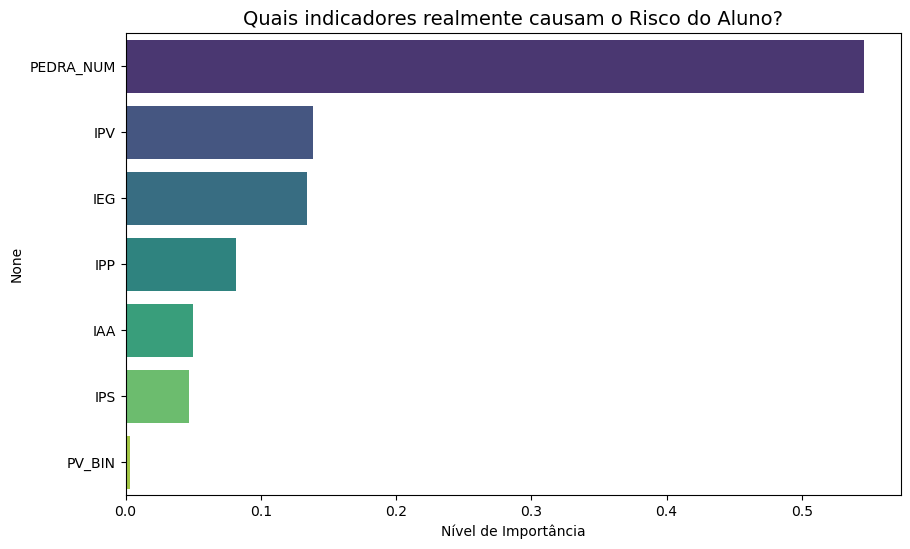

In [11]:
importancias = pd.Series(modelo_rf.feature_importances_,
                         index=features_honestas).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=importancias.index, palette='viridis')
plt.title('Quais indicadores realmente causam o Risco do Aluno?', fontsize=14)
plt.xlabel('Nível de Importância')
plt.show()

Salvamento base atualizada

In [12]:
df['PROBABILIDADE_RISCO'] = modelo_rf.predict_proba(X)[:, 1]

df.to_csv('../data/processed/pede_final_com_inteligencia.csv', index=False)
print("Base final com probabilidades de risco salva em /processed/!")

Base final com probabilidades de risco salva em /processed/!


Salvamento do modelo

In [13]:
if not os.path.exists('../models'):
    os.makedirs('../models')

joblib.dump(modelo_rf, '../models/modelo_risco_rf.pkl')
joblib.dump(features_honestas, '../models/features_modelo.pkl')

print("✅ Modelo e features salvos com sucesso na pasta /models!")

✅ Modelo e features salvos com sucesso na pasta /models!
